In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/optimal-control/code/lec7`


In [2]:
using LinearAlgebra
using SparseArrays
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
import SymPy
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [15]:
# continuous time system
A_c = [0 1; 0 0];
B_c = [0; 1];

In [29]:
# derive discrete time system using matrix exponential
h_sym = SymPy.Sym("h")
D_sym = SymPy.exp([A_c B_c; 0 0 0] * h_sym)

h = 0.1
# D = SymPy.N(D_sym.subs(h_sym, h))
D = SymPy.convert(Matrix{Float64}, D_sym.subs(h_sym, h))  # sparse matrix is sensitive to the type

A = D[1:2, 1:2]
B = D[1:2, 3]

2-element Vector{Float64}:
 0.005000000000000001
 0.1

In [30]:
n = size(A)[2]  # number of states
m = length(size(B)) == 1 ? 1 : size(B)[2]  # number of controls
t_final = 5.0  # final time (try larger values, superlinear in computation complexity increase)
t_history = Array(0:h:t_final)
N = length(t_history)  # number of time steps

51

In [31]:
# initial conditions
x0 = [1.0; 0]  # try some other states

2-element Vector{Float64}:
 1.0
 0.0

In [32]:
# cost weights
Q = sparse(1.0 * I(2))
R = sparse(0.1 * I(1))  # try larger values
Q_N = sparse(1.0 * I(2))

2×2 SparseMatrixCSC{Float64, Int64} with 2 stored entries:
 1.0   ⋅ 
  ⋅   1.0

In [33]:
function J(x_history, u_history)
    cost = 0.5 * x_history[:, end]' * Q_N * x_history[:, end]
    for k = 1:(N-1)
        cost +=
            0.5 * x_history[:, k]' * Q * x_history[:, k] +
            0.5 * (u_history[k]'*R*u_history[k])[1]  # WARNING: Now that R is a matrix instead of real number, the result is a 1x1 matrix, so use index.
    end
    return cost
end

J (generic function with 1 method)

In [34]:
# cost matrix H for reconstructed cost z^THz
H = blockdiag(R, kron(I(N - 2), blockdiag(Q, R)), Q_N);

In [35]:
# C and d for reconstructed constraints
C = kron(I(N - 1), [B -I(n)])
for k = 1:N-2
    C[(k*n).+(1:n), (k*(m+n)-n).+(1:n)] .= A
end
d = [-A * x0; zeros(size(C, 1) - n)];

In [36]:
# solve the linear system
y = [H C'; C zeros(size(C, 1), size(C, 1))] \ [zeros(size(H, 1)); d];

# Get state history
z = y[1:size(H, 1)];   # states and controls [u0,x1,u1,...,xN]
Z = reshape(z, n + m, N - 1);  # [[u0,x1],[u1,x2],...,[u_{N-1},x_N]]
x_history = Z[m+1:end, :];
x_history = [x0 x_history];

# Get control history. control only has 1 dim
u_history = Z[1, :];

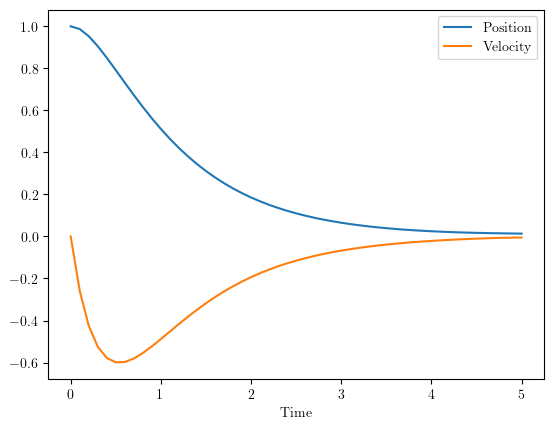

PyObject <matplotlib.legend.Legend object at 0x7f19fb03b400>

In [37]:
# Plot x1 vs. x2, u vs. t, x vs. t, etc.
plot(t_history, x_history[1, :], label = "Position")
plot(t_history, x_history[2, :], label = "Velocity")
xlabel("Time")
legend()

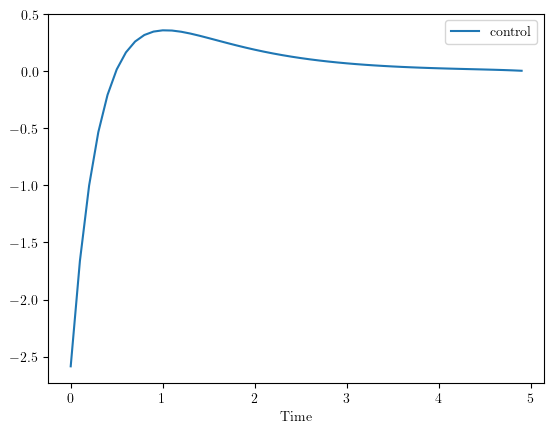

PyObject <matplotlib.legend.Legend object at 0x7f19f50acd60>

In [38]:
plot(t_history[1:end-1], u_history, label = "control")
xlabel("Time")
legend()

In [39]:
J(x_history, u_history)

6.658133166380828